# Multilayer Neural Network to make Binary Prediction on Events 
# (Stock Price Up/Down Example)
Liaohan Wang August 2024

In [15]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepare Data

In [16]:
train_data = pd.read_csv('train_data.csv')
small_train = train_data.drop(['date'], axis=1)
small_target = small_train.shift(-1)

## Balance Data : some events have significantly higher counts than others, we need to balance the data (each of them) : an entry is 1 only if the counts value is higher than the column 'median'
# a) calculate and store train dataset median for each event BEFORE convert to one-hot encode
def input_median(dataframe):
    median_dict = {}
    for column in dataframe.columns.tolist(): 
        median_dict[column] = dataframe[column].median()
    return median_dict

# b) Balance input data
def balance_data(dataframe):
    for column in dataframe.columns.tolist():
        dataframe[column] = dataframe[column].apply(lambda x: 1 if x > dataframe[column].median() else 0)
    return dataframe

# calculate median before one-hot encode
train_median_dict = input_median(small_train)
small_train = small_train.drop(index=[1285, 1286])
small_train = balance_data(small_train)

# c) Balance output data
# apply before convert train & test into one-hot encode
def balance_data_test(dataframe, input_median):
    for column in dataframe.columns.tolist():
        dataframe[column] = dataframe[column].apply(lambda x: 1 if x > input_median[column] else 0)
    return dataframe

small_target = balance_data_test(small_target, train_median_dict) 
small_target = small_target[['Stock Price Up', 'Stock Price Down']]
small_target = small_target.drop(index=[1285, 1286], axis=1)

# 2. Multilayer Neural Network Model
A model that allows customized input on hidden layer dimensions and activation function

In [17]:
train_array = small_train.to_numpy()
target_array = small_target.to_numpy()

X = torch.tensor(train_array, dtype=torch.float32)
y = torch.tensor(target_array, dtype=torch.float32)#.reshape(-1, 1)

class MultiLabelModel(nn.Module):
    def __init__(self, input_dim, hidden_layers = [500, 32], activation = 'relu'):
        super(MultiLabelModel, self).__init__()
        self.layers = nn.ModuleList()
        
        ## customized number of neurons
        for hidden_dim in hidden_layers:
            self.layers.append(nn.Linear(input_dim, hidden_dim))
            input_dim = hidden_dim

        self.output_layer = nn.Linear(input_dim, 2)  # 2 output neurons
        self.activation_fn = getattr(torch, activation)  

        ## fixed number of neurons
        '''self.layer1 = nn.Linear(input_dim, 500) # 500 hidden nodes
        self.layer2 = nn.Linear(500, 32)
        self.layer3 = nn.Linear(32, 2) # last number is the number of output vars
        self.sigmoid = nn.Sigmoid()'''
    
    def forward(self, x):
        ## customized activation functions
        for layer in self.layers:
            x = self.activation_fn(layer(x))  # Apply activation function after each layer
        x = torch.sigmoid(self.output_layer(x))  # Sigmoid for output layer
        return x
    
        ## fixed activation functions
        '''x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x'''
    
model = MultiLabelModel(input_dim=X.shape[1])
loss_fn = nn.BCEWithLogitsLoss()  # For multi-label classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Train
A function that allows customized input on model, number of epochs, and batch size

In [18]:
def train(model, n_epochs=100, batch_size=10):
    loss_list = []
    loss_fn = nn.BCEWithLogitsLoss()  # For multi-label classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(n_epochs):
        epoch_loss = 0  
        for i in range(0, len(X), batch_size):
            Xbatch = X[i:i+batch_size]
            y_pred = model(Xbatch)
            ybatch = torch.tensor(small_target.to_numpy()[i:i+batch_size], dtype=torch.float32)  # target values

            loss = loss_fn(y_pred, ybatch)
            optimizer.zero_grad()  
            loss.backward()  # Computes dloss/dx for every parameter x 
            optimizer.step()
            epoch_loss += loss.item()  
            
        avg_epoch_loss = epoch_loss / (len(X) // batch_size)  # average loss for the epoch
        loss_list.append(avg_epoch_loss)  
        #print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_epoch_loss:.4f}')

    plt.plot(range(1, n_epochs + 1), loss_list, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss vs. Epoch')
    plt.grid(True)
    plt.show()

    # loss at the last iteration
    final_loss = loss_list[-1] 
    print(f'Final Loss: {final_loss:.4f}')

## 3. a) Hypoerparameter Tuning (# of hidden layer neurons, activation function, # of epochs, batch size)
<br> The loss is decreasing as we are iterating more data to train our model, as epoch approaching 100, there is no significant change in loss anymore, it tends to be stable. Thus, we use epoch=100.
<br> optimal : [n_epochs: 500, batch_size: 5, hidden_layers: [1000, 64], activation: relu]
<br> activation functions : 'relu' best, 'sigmoid' worst

In [19]:
'''
import itertools

paramets = {
    "hidden_layers": [[1000, 32], [1000, 64]],
    "activation": ['relu'],
    "n_epochs": [100, 500],
    "batch_size": [10, 5]
}

for n_epochs, batch_size, hidden_layers, activation in itertools.product(paramets['n_epochs'], paramets['batch_size'], paramets["hidden_layers"], paramets["activation"]):
    print(f'n_epochs:', n_epochs, f'batch_size:', batch_size, f'hidden_layers:', hidden_layers, f'activation:', activation)
    model = MultiLabelModel(input_dim=X.shape[1], hidden_layers=hidden_layers, activation=activation)
    
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train(model=model, n_epochs=n_epochs, batch_size=batch_size)
'''

'\nimport itertools\n\nparamets = {\n    "hidden_layers": [[1000, 32], [1000, 64]],\n    "activation": [\'relu\'],\n    "n_epochs": [100, 500],\n    "batch_size": [10, 5]\n}\n\nfor n_epochs, batch_size, hidden_layers, activation in itertools.product(paramets[\'n_epochs\'], paramets[\'batch_size\'], paramets["hidden_layers"], paramets["activation"]):\n    print(f\'n_epochs:\', n_epochs, f\'batch_size:\', batch_size, f\'hidden_layers:\', hidden_layers, f\'activation:\', activation)\n    model = MultiLabelModel(input_dim=X.shape[1], hidden_layers=hidden_layers, activation=activation)\n    \n    loss_fn = nn.BCEWithLogitsLoss()\n    optimizer = optim.Adam(model.parameters(), lr=0.001)\n    train(model=model, n_epochs=n_epochs, batch_size=batch_size)\n'

#### optimal : n_epochs: 500, batch_size: 10, hidden_layers: [1000, 64], activation: relu
loss <= 0.529

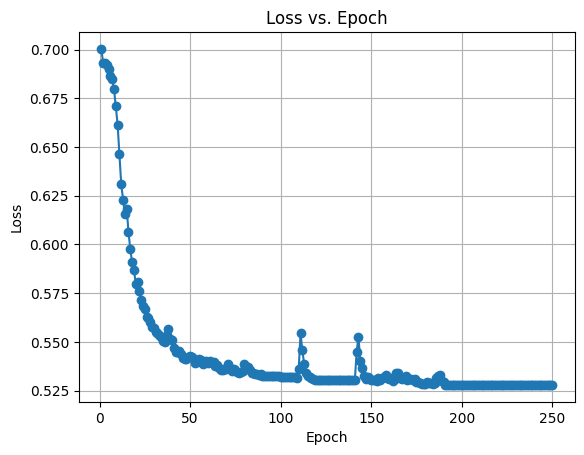

Final Loss: 0.5279


In [36]:
optmial_model = MultiLabelModel(input_dim=X.shape[1], hidden_layers=[1000, 64], activation='relu')
#train(model=optmial_model, n_epochs=500, batch_size=5)
train(model=optmial_model, n_epochs=250, batch_size=5)

# 4. Evaluate Test Data

## 4. a) Prepare Test Data

In [37]:
test_data = pd.read_csv('test_data.csv')
test_x = test_data.drop(['date'], axis=1)
test_target = test_x.shift(-1)
test = pd.concat([test_x, test_target], axis=1)

# calculate median before applying one-hot encoding
test_median_dict = input_median(test_x)
test_x = balance_data(test_x)
test_x = test_x.drop(index=[376])

# compare w input median
test_target = balance_data_test(test_target, test_median_dict)
test_target = test_target[['Stock Price Up', 'Stock Price Down']]
test_target = test_target.drop(index=[376])

test_array = test_x.to_numpy()
target_array = test_target.to_numpy()

X_test = torch.tensor(test_array, dtype=torch.float32)
y_true = torch.tensor(target_array, dtype=torch.float32)#.reshape(-1, 1)

## 4. b) Test Model

In [38]:
y_pred = optmial_model(X_test)

stock_price_up_pred = []
stock_price_down_pred = []

for i in range(len(y_pred)-1):
    left = y_pred[i, 0].item()
    stock_price_up_pred.append(left)

    right = y_pred[i, 1].item()
    stock_price_down_pred.append(right)


stock_price_up_true = []
stock_price_down_true = []

for i in range(len(y_true)-1):
    left = y_true[i, 0].item()
    stock_price_up_true.append(left)

    right = y_true[i, 1].item()
    stock_price_down_true.append(right)


## 4. c) Evaluate Model Using Test Data

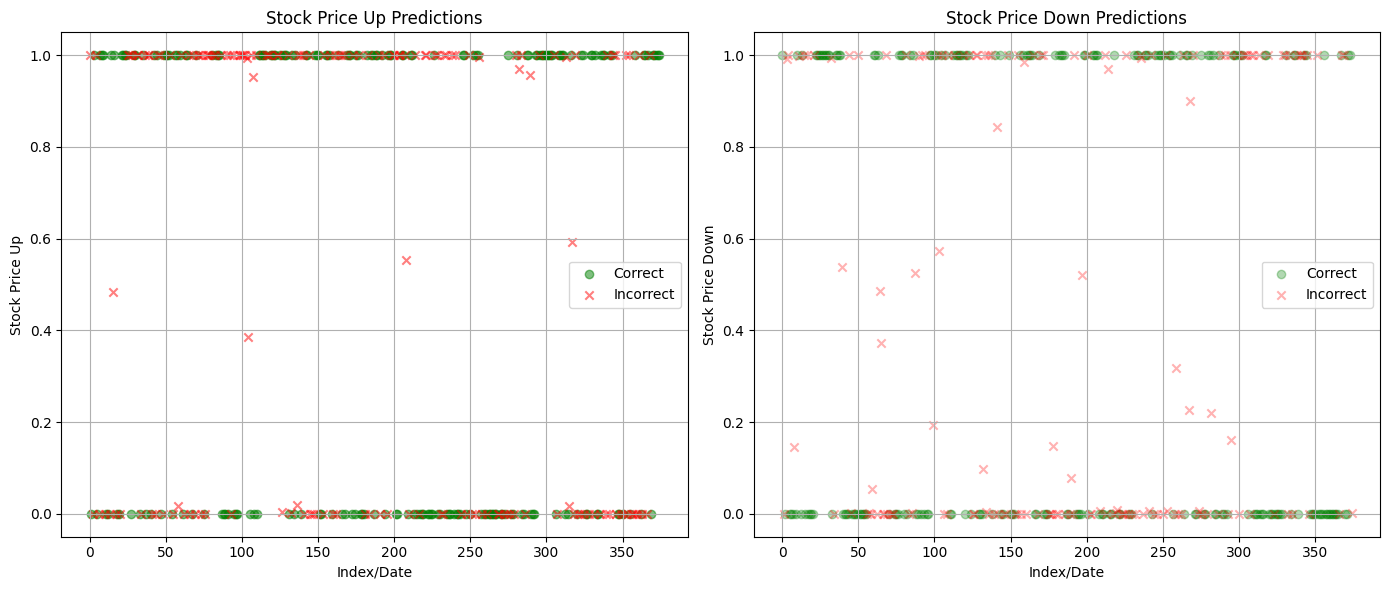

In [39]:
stock_price_up_pred = np.array(stock_price_up_pred)
stock_price_down_pred = np.array(stock_price_down_pred)
stock_price_up_true = np.array(stock_price_up_true)
stock_price_down_true = np.array(stock_price_down_true)
plt.figure(figsize=(14, 6))

#### stock price UP predictions
plt.subplot(1, 2, 1)
correct_up = stock_price_up_pred.round() == stock_price_up_true
accuracy_up = np.mean(correct_up)
correct_up_indices = np.where(correct_up)[0]
incorrect_up_indices = np.where(~correct_up)[0]

plt.scatter(correct_up_indices, stock_price_up_true[correct_up_indices], 
            color='green', marker='o', label='Correct', alpha=0.5)
plt.scatter(incorrect_up_indices, stock_price_up_pred[incorrect_up_indices], 
            color='red', marker='x', label='Incorrect', alpha=0.5)

plt.xlabel('Index/Date')
plt.ylabel('Stock Price Up')
plt.title('Stock Price Up Predictions')
plt.legend()
plt.grid(True)

#### stock price DOWN predictions
plt.subplot(1, 2, 2)
correct_down = stock_price_down_pred.round() == stock_price_down_true
accuracy_down = np.mean(correct_down)
correct_down_indices = np.where(correct_down)[0]
incorrect_down_indices = np.where(~correct_down)[0]

plt.scatter(correct_down_indices, stock_price_down_true[correct_down_indices], 
            color='green', marker='o', label='Correct', alpha=0.3)
plt.scatter(incorrect_down_indices, stock_price_down_pred[incorrect_down_indices], 
            color='red', marker='x', label='Incorrect', alpha=0.3)

plt.xlabel('Index/Date') 
plt.ylabel('Stock Price Down')
plt.title('Stock Price Down Predictions')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

A funtion to evaluate each pair of true and prediction data

In [40]:
def evaluate(true, pred):
    if torch.is_tensor(true) or torch.is_tensor(pred):
        true = true.detach().numpy()
        pred = pred.detach().numpy()

    # accuracy
    accuracy = np.mean(pred.round() == true)
    print(f'Accuracy:', accuracy)

    # Precision = true positive / total predicted positive
    true_pos = ((true == pred.round()) & (true == 1)).sum()
    total_pred_pos = (pred.round() == 1).sum()
    precision = true_pos / total_pred_pos
    print(f'Precision:', precision)

    # Recall = true positive / total actual positive
    total_actual_pos = (true == 1).sum()
    recall = true_pos / total_actual_pos
    print(f'Recall:', recall)

### Stock Price Up

In [41]:
evaluate(stock_price_up_true, stock_price_up_pred)

Accuracy: 0.5653333333333334
Precision: 0.5603864734299517
Recall: 0.6170212765957447


### Stock Price Down

In [42]:
evaluate(stock_price_down_true, stock_price_down_pred)

Accuracy: 0.584
Precision: 0.5882352941176471
Recall: 0.5376344086021505


### Overall

In [43]:
evaluate(y_true, y_pred)

Accuracy: 0.5757978723404256
Precision: 0.5729442970822282
Recall: 0.5775401069518716


# References
- https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/
- https://realpython.com/python-ai-neural-network/